# Federated Learning Project Specification Notebook (NSL-KDD)

**Project:** Cybersecurity Intrusion Detection with Federated Learning  
**Dataset:** NSL-KDD (Kaggle TXT files)  
**Owner:** Aswin P T  
**Date:** April 2026

## Objective
Build and evaluate a binary intrusion detector (`normal` vs `attack`) using:
1. A centralized baseline model
2. A federated model trained with Flower (FedAvg)

Then compare both systems on the held-out test set.

## Todo List
- [x] Load NSL-KDD TXT files with manual column names
- [x] Convert labels to binary attack/normal targets
- [x] One-hot encode categorical fields
- [x] Fit train-only scaler and prepare tensors
- [x] Train centralized baseline model
- [x] Save centralized model and metrics
- [x] Partition training data into isolated client shards
- [x] Build per-client loaders and scalers
- [x] Run federated Flower simulation
- [x] Save aggregated global model
- [x] Evaluate federated model on held-out test set
- [x] Build comparison metrics and plots

## Dataset Rules Enforced in This Notebook
- Only `.txt` files are used (`.arff` files are ignored).
- Files contain **no header row**; all 43 columns are assigned manually.
- `difficulty` is dropped before modeling.
- Label mapping: `normal -> 0`, all other labels -> `1`.
- Categorical columns (`protocol_type`, `service`, `flag`) are one-hot encoded.

## Reduced Federated Setup
- 6 simulated clients total
- 3 clients participate in each round
- 20 communication rounds
- This setup is large enough to show federation effects while still being practical on a single machine.

## Expected Core Artifacts
- `scaler.pkl`
- `centralized_baseline.pt`
- `baseline_metrics.json`
- `client_data.pkl`
- `global_federated_model.npy`
- `results_comparison.csv`

## Execution Status
All core cells in the notebook have been executed successfully.

In [2]:
import importlib
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path(".").resolve()

print(f"Device: {DEVICE}")
print(f"Workspace: {ROOT}")

flwr_available = importlib.util.find_spec("flwr") is not None
print(f"Flower available: {flwr_available}")

Device: cpu
Workspace: D:\synbrains internship\federated_learning_project
Flower available: True


In [3]:
# Column names: 41 features + label + difficulty
COL_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

CATEGORICAL_COLS = ["protocol_type", "service", "flag"]

DOS = {"back", "land", "neptune", "pod", "smurf", "teardrop", "mailbomb", "apache2", "processtable", "udpstorm"}
PROBE = {"ipsweep", "nmap", "portsweep", "satan", "mscan", "saint"}
R2L = {"ftp_write", "guess_passwd", "imap", "multihop", "phf", "spy", "warezclient", "warezmaster", "sendmail", "named", "snmpgetattack"}
U2R = {"buffer_overflow", "loadmodule", "perl", "rootkit", "httptunnel", "ps", "sqlattack"}

ATTACK_GROUPS = {
    "DoS": DOS,
    "Probe": PROBE,
    "R2L": R2L,
    "U2R": U2R,
}

def map_attack_group(label: str) -> str:
    if label == "normal":
        return "Normal"
    for group, members in ATTACK_GROUPS.items():
        if label in members:
            return group
    return "OtherAttack"

TRAIN_FILE = ROOT / "KDDTrain+.txt"
TRAIN20_FILE = ROOT / "KDDTrain+_20Percent.txt"
TEST_FILE = ROOT / "KDDTest+.txt"
HARD_TEST_FILE = ROOT / "KDDTest-21.txt"

print("Dataset files present:")
for p in [TRAIN_FILE, TRAIN20_FILE, TEST_FILE, HARD_TEST_FILE]:
    print(f"- {p.name}: {p.exists()}")

Dataset files present:
- KDDTrain+.txt: True
- KDDTrain+_20Percent.txt: True
- KDDTest+.txt: True
- KDDTest-21.txt: True


## Environment and Dataset Constants

This cell defines the KDD feature schema, attack group mappings, and file paths used throughout the notebook.

## Phase 1 - Data Preparation and Centralized Baseline

### Purpose
Establish the centralized reference performance that all federated outcomes are compared against.

### Phase 1 Checklist
1. Load `KDDTrain+.txt` and `KDDTest+.txt` with explicit 43-column schema.
2. Run basic EDA (class distribution and categorical value counts).
3. Drop `difficulty`; convert labels to binary.
4. One-hot encode `protocol_type`, `service`, and `flag`.
5. Split train/validation as 80/20 using stratification.
6. Fit `StandardScaler` on training split only.
7. Train MLP baseline with weighted BCE loss and early stopping.
8. Evaluate once on held-out test and save metrics/artifacts.

### Notes
- The test set is held out for evaluation; no fitting or tuning should use test information.
- Macro precision/recall/F1 and AUC are tracked to avoid misleading accuracy-only conclusions.

In [4]:
def load_raw(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=COL_NAMES)
    return df

train_raw = load_raw(TRAIN_FILE)
test_raw = load_raw(TEST_FILE)

print("Shapes (expected train ~125973x43, test ~22543x43):")
print("train:", train_raw.shape)
print("test :", test_raw.shape)

print("Null counts (top 10 columns):")
print(train_raw.isna().sum().sort_values(ascending=False).head(10))

# Basic EDA summaries requested in spec
print("\nprotocol_type counts:\n", train_raw["protocol_type"].value_counts().head(10))
print("\nservice counts (top 10):\n", train_raw["service"].value_counts().head(10))
print("\nflag counts:\n", train_raw["flag"].value_counts().head(20))

Shapes (expected train ~125973x43, test ~22543x43):
train: (125973, 43)
test : (22544, 43)
Null counts (top 10 columns):
duration          0
protocol_type     0
service           0
flag              0
src_bytes         0
dst_bytes         0
land              0
wrong_fragment    0
urgent            0
hot               0
dtype: int64

protocol_type counts:
 protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

service counts (top 10):
 service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

flag counts:
 flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


In [5]:
def preprocess_for_binary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["attack_group"] = out["label"].apply(map_attack_group)
    out = out.drop(columns=["difficulty"])  # meta-label not used as feature
    out["label"] = (out["label"] != "normal").astype(int)
    return out

train_proc = preprocess_for_binary(train_raw)
test_proc = preprocess_for_binary(test_raw)

print("Binary label distribution (train):")
print(train_proc["label"].value_counts())
print("Attack group distribution (train):")
print(train_proc["attack_group"].value_counts())

# Encode categorical features and align train/test columns
train_encoded = pd.get_dummies(train_proc.drop(columns=["attack_group"]), columns=CATEGORICAL_COLS)
test_encoded = pd.get_dummies(test_proc.drop(columns=["attack_group"]), columns=CATEGORICAL_COLS)

y_train_full = train_encoded["label"].values.astype(np.float32)
y_test = test_encoded["label"].values.astype(np.float32)

X_train_full_df = train_encoded.drop(columns=["label"])
X_test_df = test_encoded.drop(columns=["label"])

X_test_df = X_test_df.reindex(columns=X_train_full_df.columns, fill_value=0)

print("Encoded feature count (spec target: 112):", X_train_full_df.shape[1])

Binary label distribution (train):
label
0    67343
1    58630
Name: count, dtype: int64
Attack group distribution (train):
attack_group
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
Encoded feature count (spec target: 112): 122


## Label Binarization and Encoding

This step drops the difficulty score, maps attacks to binary labels, and expands categorical fields with one-hot encoding.

In [6]:
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_train_full_df,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

print("Train/Val sizes:", X_train_df.shape, X_val_df.shape)

# Defensive missing-value handling as required in spec
for frame_name, frame in [("train", X_train_df), ("val", X_val_df), ("test", X_test_df)]:
    nan_count = int(frame.isna().sum().sum())
    print(f"NaN check {frame_name}: {nan_count}")

if X_train_df.isna().sum().sum() > 0:
    numeric_cols = X_train_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        median = X_train_df[col].median()
        X_train_df[col] = X_train_df[col].fillna(median)
        X_val_df[col] = X_val_df[col].fillna(median)
        X_test_df[col] = X_test_df[col].fillna(median)

# StandardScaler fit on train only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_val = scaler.transform(X_val_df.values)
X_test = scaler.transform(X_test_df.values)

with open(ROOT / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved scaler.pkl")

Train/Val sizes: (100778, 122) (25195, 122)
NaN check train: 0
NaN check val: 0
NaN check test: 0
Saved scaler.pkl


In [7]:
def to_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=256, shuffle=True)
val_loader = to_loader(X_val, y_val, batch_size=256, shuffle=False)
test_loader = to_loader(X_test, y_test, batch_size=512, shuffle=False)

class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = MLPClassifier(input_dim=input_dim).to(DEVICE)

n_pos = float((y_train == 1).sum())
n_neg = float((y_train == 0).sum())
pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Input dim: {input_dim}, pos_weight: {float(pos_weight.item()):.4f}")

Input dim: 122, pos_weight: 1.1486


Epoch 01 | train_loss=0.0714 val_loss=0.0261 val_acc=0.9920
Epoch 02 | train_loss=0.0283 val_loss=0.0240 val_acc=0.9920
Epoch 03 | train_loss=0.0263 val_loss=0.0218 val_acc=0.9919
Epoch 04 | train_loss=0.0239 val_loss=0.0223 val_acc=0.9912
Epoch 05 | train_loss=0.0228 val_loss=0.0212 val_acc=0.9921
Epoch 06 | train_loss=0.0213 val_loss=0.0191 val_acc=0.9938
Epoch 07 | train_loss=0.0217 val_loss=0.0191 val_acc=0.9935
Epoch 08 | train_loss=0.0203 val_loss=0.0188 val_acc=0.9939
Epoch 09 | train_loss=0.0203 val_loss=0.0176 val_acc=0.9935
Epoch 10 | train_loss=0.0195 val_loss=0.0176 val_acc=0.9941
Epoch 11 | train_loss=0.0191 val_loss=0.0181 val_acc=0.9939
Epoch 12 | train_loss=0.0180 val_loss=0.0162 val_acc=0.9945
Epoch 13 | train_loss=0.0179 val_loss=0.0168 val_acc=0.9940
Epoch 14 | train_loss=0.0172 val_loss=0.0157 val_acc=0.9947
Epoch 15 | train_loss=0.0169 val_loss=0.0157 val_acc=0.9948
Epoch 16 | train_loss=0.0172 val_loss=0.0150 val_acc=0.9952
Epoch 17 | train_loss=0.0163 val_loss=0.

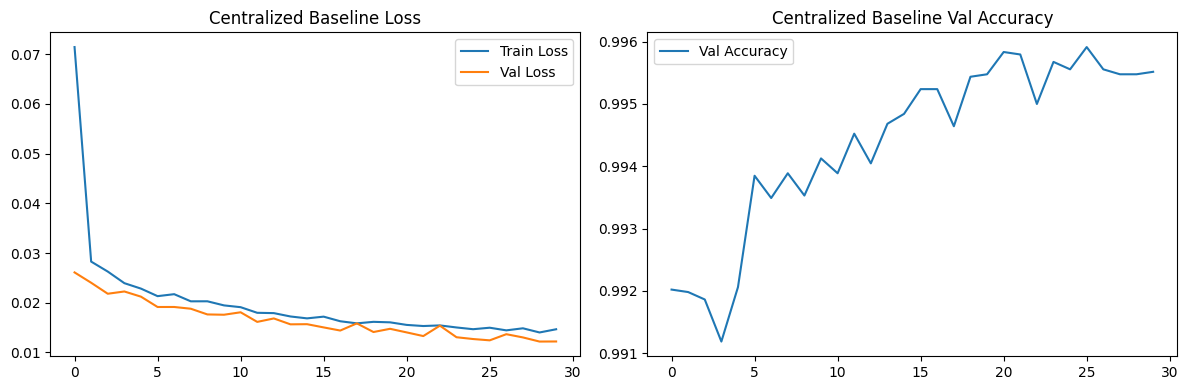

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    all_probs, all_targets = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(yb.detach().cpu().numpy().ravel())
        total_loss += float(loss.item()) * len(xb)

    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(targets, preds),
        "precision_macro": precision_score(targets, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(targets, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(targets, preds, average="macro", zero_division=0),
    }
    try:
        metrics["auc"] = roc_auc_score(targets, probs)
    except ValueError:
        metrics["auc"] = np.nan
    return metrics

max_epochs = 30
patience = 5
best_val_loss = float("inf")
wait = 0
history = {"train_loss": [], "val_loss": [], "val_accuracy": []}

for epoch in range(1, max_epochs + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        wait = 0
        torch.save(model.state_dict(), ROOT / "centralized_baseline.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.")
            break

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Centralized Baseline Loss")

plt.subplot(1, 2, 2)
plt.plot(history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Centralized Baseline Val Accuracy")
plt.tight_layout()
plt.show()

Saved centralized_baseline.pt and baseline_metrics.json
{
  "accuracy": 0.809528034066714,
  "precision_macro": 0.8353754698488995,
  "recall_macro": 0.8292022124667442,
  "f1_macro": 0.8093866409963444,
  "auc": 0.914908172612566,
  "confusion_matrix": [
    [
      9432,
      279
    ],
    [
      4015,
      8818
    ]
  ]
}


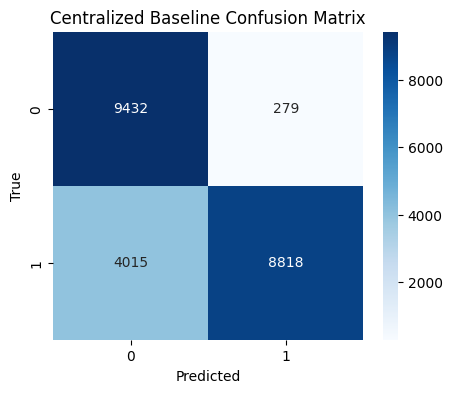

In [9]:
# Baseline test evaluation and artifact save
best_model = MLPClassifier(input_dim=input_dim).to(DEVICE)
best_model.load_state_dict(torch.load(ROOT / "centralized_baseline.pt", map_location=DEVICE))

with torch.no_grad():
    test_metrics = run_epoch(best_model, test_loader, criterion, optimizer=None)

# Collect confusion matrix with explicit predictions
all_probs, all_targets = [], []
best_model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        probs = torch.sigmoid(best_model(xb)).cpu().numpy().ravel()
        all_probs.append(probs)
        all_targets.append(yb.numpy().ravel())

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets).astype(int)
all_preds = (all_probs >= 0.5).astype(int)
cm = confusion_matrix(all_targets, all_preds)

baseline_metrics = {
    "accuracy": float(test_metrics["accuracy"]),
    "precision_macro": float(test_metrics["precision_macro"]),
    "recall_macro": float(test_metrics["recall_macro"]),
    "f1_macro": float(test_metrics["f1_macro"]),
    "auc": float(test_metrics["auc"]),
    "confusion_matrix": cm.tolist(),
}

with open(ROOT / "baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, indent=2)

print("Saved centralized_baseline.pt and baseline_metrics.json")
print(json.dumps(baseline_metrics, indent=2))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Centralized Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Phase 2 - Simulating Distributed Clients

### Purpose
Transform centralized training data into isolated client shards to mimic a realistic federated environment.

### Strategy
- Primary mode: **Non-IID partitioning** with label/attack skew across 6 clients.
- Reference mode: IID split for comparison (optional).

### Required Validations
1. All client shards together cover the full training pool.
2. No overlap between client indices.
3. Each client has its own local `StandardScaler` fitted only on local data.

### Output of This Phase
- `client_loaders` for local training.
- `client_data.pkl` containing per-client processed arrays.

In [15]:
# Rebuild attack-group labels for partitioning from preprocessed train set
train_groups = train_proc.loc[X_train_df.index, "attack_group"].reset_index(drop=True)
X_train_np = X_train_df.reset_index(drop=True).values
y_train_np = y_train.astype(np.float32)


def partition_noniid_indices(groups: pd.Series, n_clients: int = 6, seed: int = 42):
    rng = np.random.default_rng(seed)
    indices_by_group = {
        "Normal": np.where(groups.values == "Normal")[0],
        "DoS": np.where(groups.values == "DoS")[0],
        "Probe": np.where(groups.values == "Probe")[0],
        "R2L": np.where(groups.values == "R2L")[0],
        "U2R": np.where(groups.values == "U2R")[0],
        "OtherAttack": np.where(groups.values == "OtherAttack")[0],
    }

    for arr in indices_by_group.values():
        rng.shuffle(arr)

    client_indices = {i: [] for i in range(n_clients)}

    # 6-client layout: 2 DoS-heavy, 1 Probe-heavy, 1 Normal-heavy, 1 R2L-heavy, 1 mixed rare-attacks client
    layout = {
        0: ["DoS", "Normal"],
        1: ["DoS", "Normal"],
        2: ["Probe", "Normal"],
        3: ["Normal", "DoS"],
        4: ["R2L", "U2R", "Normal"],
        5: ["OtherAttack", "R2L", "U2R", "Probe", "DoS", "Normal"],
    }

    group_splits = {
        name: list(np.array_split(arr, max(1, sum(name in groups for groups in layout.values()))))
        for name, arr in indices_by_group.items()
    }

    group_cursor = {name: 0 for name in indices_by_group}
    for cid in range(n_clients):
        for group_name in layout[cid]:
            arr_list = group_splits[group_name]
            cursor = group_cursor[group_name]
            if cursor < len(arr_list):
                client_indices[cid].extend(arr_list[cursor].tolist())
                group_cursor[group_name] += 1

    used = set()
    cleaned = {}
    for cid in range(n_clients):
        uniq = []
        for idx in client_indices[cid]:
            if idx not in used:
                uniq.append(idx)
                used.add(idx)
        cleaned[cid] = np.array(uniq, dtype=np.int64)

    remaining = np.array(sorted(list(set(range(len(groups))) - used)), dtype=np.int64)
    for cid, split in zip(range(n_clients), np.array_split(remaining, n_clients)):
        cleaned[cid] = np.concatenate([cleaned[cid], split]) if len(cleaned[cid]) else split

    return cleaned


def partition_iid_indices(n_samples: int, n_clients: int = 6, seed: int = 42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    return {cid: split for cid, split in enumerate(np.array_split(idx, n_clients))}

n_clients = 6
noniid_indices = partition_noniid_indices(train_groups, n_clients=n_clients, seed=SEED)
iid_indices = partition_iid_indices(len(X_train_np), n_clients=n_clients, seed=SEED)

print("Client shard stats (Non-IID):")
for cid in range(n_clients):
    idx = noniid_indices[cid]
    y_c = y_train_np[idx]
    g_c = train_groups.iloc[idx]
    print(
        f"Client {cid}: n={len(idx)} | attack={y_c.mean():.3f} | "
        f"DoS={(g_c=='DoS').mean():.3f} Probe={(g_c=='Probe').mean():.3f} "
        f"R2L/U2R={((g_c=='R2L') | (g_c=='U2R') | (g_c=='OtherAttack')).mean():.3f}"
    )

all_idx = np.concatenate([noniid_indices[cid] for cid in range(n_clients)])
assert len(np.unique(all_idx)) == len(X_train_np), "Overlap detected in non-IID partition"
assert len(all_idx) == len(X_train_np), "Coverage mismatch in non-IID partition"
print("Isolation check passed for non-IID partition.")

Client shard stats (Non-IID):
Client 0: n=18185 | attack=0.506 | DoS=0.506 Probe=0.000 R2L/U2R=0.000
Client 1: n=18185 | attack=0.506 | DoS=0.506 Probe=0.000 R2L/U2R=0.000
Client 2: n=13613 | attack=0.340 | DoS=0.000 Probe=0.340 R2L/U2R=0.000
Client 3: n=18184 | attack=0.506 | DoS=0.506 Probe=0.000 R2L/U2R=0.000
Client 4: n=9387 | attack=0.043 | DoS=0.000 Probe=0.000 R2L/U2R=0.043
Client 5: n=23224 | attack=0.613 | DoS=0.396 Probe=0.199 R2L/U2R=0.018
Isolation check passed for non-IID partition.


## Client Partitioning and Local Loaders

This section constructs the non-IID client shards, verifies isolation, and builds one scaler and dataloader per client.

In [16]:
# Build per-client scaled arrays and loaders (non-IID primary)
client_scalers = []
client_loaders = []
client_data = []

for cid in range(n_clients):
    idx = noniid_indices[cid]
    X_c = X_train_np[idx]
    y_c = y_train_np[idx]

    scaler_c = StandardScaler()
    X_c_scaled = scaler_c.fit_transform(X_c)

    loader_c = to_loader(X_c_scaled, y_c, batch_size=64, shuffle=True)

    client_scalers.append(scaler_c)
    client_loaders.append(loader_c)
    client_data.append((X_c_scaled.astype(np.float32), y_c.astype(np.float32)))

print(f"Built {len(client_loaders)} client loaders.")
print("Total rows across clients:", sum(len(cd[1]) for cd in client_data))

with open(ROOT / "client_data.pkl", "wb") as f:
    pickle.dump(client_data, f)
print("Saved client_data.pkl")

Built 6 client loaders.
Total rows across clients: 100778
Saved client_data.pkl


## Feature Scaling and Tensor Preparation

The train split is scaled once for the centralized baseline, then converted into PyTorch tensors and dataloaders.

## Phase 3 - Federated Training with Flower (FedAvg)

### Purpose
Train a global model across decentralized clients without sharing raw records.

### Configuration
- Total clients: `6`
- Clients participating per round: `3` (`fraction_fit=0.5`)
- Communication rounds: `20`
- Local epochs per selected client: `3`
- Aggregation: **FedAvg** (weighted by client sample count)

### Server Monitoring
After each round, evaluate aggregated weights on centralized validation data and log:
- Validation loss
- Validation accuracy
- Validation macro F1

### Output of This Phase
- `global_federated_model.npy` (final aggregated parameters)
- Round-wise convergence curve(s)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=20, no round_timeout
2026-04-21 12:54:57,769	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 203791564.0, 'GPU': 1.0, 'memory': 475513652.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'accelerator_type:G': 1.0, 'CPU': 12.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resou

Federated simulation complete. Saved global_federated_model.npy


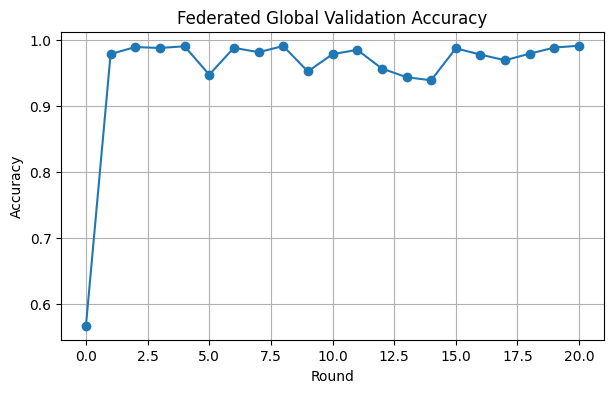

In [17]:
if not flwr_available:
    print("Flower not installed. Install with: pip install flwr[simulation]")
else:
    import flwr as fl
    from collections import OrderedDict

    def get_parameters(net):
        return [val.cpu().numpy() for _, val in net.state_dict().items()]

    def set_parameters(net, parameters):
        params_dict = zip(net.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        net.load_state_dict(state_dict, strict=True)

    class CyberSecClient(fl.client.NumPyClient):
        def __init__(self, cid, model, loader):
            self.cid = cid
            self.model = model
            self.loader = loader
            self.criterion = nn.BCEWithLogitsLoss()
            self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3, weight_decay=1e-4)

        def get_parameters(self, config):
            return get_parameters(self.model)

        def fit(self, parameters, config):
            set_parameters(self.model, parameters)
            local_epochs = int(config.get("local_epochs", 3))
            for _ in range(local_epochs):
                _ = run_epoch(self.model, self.loader, self.criterion, optimizer=self.optimizer)
            metrics = run_epoch(self.model, self.loader, self.criterion, optimizer=None)
            return get_parameters(self.model), len(self.loader.dataset), {"train_loss": float(metrics["loss"])}

        def evaluate(self, parameters, config):
            set_parameters(self.model, parameters)
            metrics = run_epoch(self.model, self.loader, self.criterion, optimizer=None)
            return float(metrics["loss"]), len(self.loader.dataset), {"accuracy": float(metrics["accuracy"])}

    def client_fn(cid: str):
        cid_int = int(cid)
        local_model = MLPClassifier(input_dim=input_dim).to(DEVICE)
        return CyberSecClient(cid=cid_int, model=local_model, loader=client_loaders[cid_int])

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    def get_eval_fn():
        def evaluate(server_round, parameters, config):
            eval_model = MLPClassifier(input_dim=input_dim).to(DEVICE)
            set_parameters(eval_model, parameters)
            eval_model.eval()
            with torch.no_grad():
                logits = eval_model(X_val_tensor)
                loss = nn.BCEWithLogitsLoss()(logits, y_val_tensor).item()
                probs = torch.sigmoid(logits).cpu().numpy().ravel()
                preds = (probs >= 0.5).astype(int)
                y_true = y_val_tensor.cpu().numpy().ravel().astype(int)
            return float(loss), {
                "val_accuracy": float(accuracy_score(y_true, preds)),
                "val_f1": float(f1_score(y_true, preds, average="macro", zero_division=0)),
            }
        return evaluate

    class SaveModelStrategy(fl.server.strategy.FedAvg):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.final_parameters = None

        def aggregate_fit(self, server_round, results, failures):
            aggregated = super().aggregate_fit(server_round, results, failures)
            if aggregated is not None:
                parameters_aggregated, metrics_aggregated = aggregated
                self.final_parameters = parameters_aggregated
                return parameters_aggregated, metrics_aggregated
            return aggregated

    strategy = SaveModelStrategy(
        fraction_fit=0.5,
        fraction_evaluate=0.5,
        min_fit_clients=3,
        min_available_clients=6,
        evaluate_fn=get_eval_fn(),
        on_fit_config_fn=lambda rnd: {"local_epochs": 3},
    )

    history = fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=6,
        config=fl.server.ServerConfig(num_rounds=20),
        strategy=strategy,
    )

    if strategy.final_parameters is not None:
        final_ndarrays = fl.common.parameters_to_ndarrays(strategy.final_parameters)
        np.save(ROOT / "global_federated_model.npy", np.array(final_ndarrays, dtype=object), allow_pickle=True)
        print("Federated simulation complete. Saved global_federated_model.npy")
    else:
        print("Warning: no final aggregated parameters captured.")

    if "val_accuracy" in history.metrics_centralized:
        rounds = [r for r, _ in history.metrics_centralized["val_accuracy"]]
        acc_values = [v for _, v in history.metrics_centralized["val_accuracy"]]
        plt.figure(figsize=(7, 4))
        plt.plot(rounds, acc_values, marker="o")
        plt.title("Federated Global Validation Accuracy")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.show()

## Flower Federated Simulation

This section defines the Flower client, server evaluation function, FedAvg strategy, and launches the federated simulation.

## Phase 4 - Held-Out Test Evaluation and Final Comparison

### Purpose
Evaluate the final federated global model on `KDDTest+.txt` and compare against the centralized baseline.

### Evaluation Protocol
1. Load centralized scaler and apply same feature-space transform to test data.
2. Run federated model inference (sigmoid + threshold `0.5`).
3. Compute: Accuracy, Macro Precision, Macro Recall, Macro F1, AUC, Confusion Matrix.
4. Load centralized baseline metrics and build side-by-side comparison.

### Deliverables
- `results_comparison.csv`
- Comparative metric bar chart
- Side-by-side confusion matrix visualization

### Interpretation Goal
Quantify the trade-off between centralized performance and federated privacy-preserving training.

In [18]:
federated_metrics = None

global_path = ROOT / "global_federated_model.npy"
if global_path.exists():
    fed_model = MLPClassifier(input_dim=input_dim).to(DEVICE)
    fed_params = np.load(global_path, allow_pickle=True)

    # Load numpy parameter list into model
    state_items = list(fed_model.state_dict().items())
    if len(fed_params) == len(state_items):
        new_state = {}
        for (k, _), arr in zip(state_items, fed_params):
            new_state[k] = torch.tensor(arr)
        fed_model.load_state_dict(new_state, strict=True)

        fed_model.eval()
        all_probs, all_targets = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(DEVICE)
                probs = torch.sigmoid(fed_model(xb)).cpu().numpy().ravel()
                all_probs.append(probs)
                all_targets.append(yb.numpy().ravel())

        y_true = np.concatenate(all_targets).astype(int)
        y_prob = np.concatenate(all_probs)
        y_pred = (y_prob >= 0.5).astype(int)

        federated_metrics = {
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
            "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
            "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
            "auc": float(roc_auc_score(y_true, y_prob)),
            "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
        }

        print("Federated metrics on held-out test:")
        print(json.dumps(federated_metrics, indent=2))
    else:
        print("global_federated_model.npy shape mismatch with model state_dict.")
else:
    print("global_federated_model.npy not found; run Phase 3 first.")

Federated metrics on held-out test:
{
  "accuracy": 0.8060237757274663,
  "precision_macro": 0.8325604875555788,
  "recall_macro": 0.8259112692510587,
  "f1_macro": 0.8058578825063696,
  "auc": 0.8721695389975305,
  "confusion_matrix": [
    [
      9415,
      296
    ],
    [
      4077,
      8756
    ]
  ]
}


## Held-Out Test Evaluation

The saved global federated model is loaded and evaluated once on KDDTest+ using the centralized feature space.

         model  accuracy  precision_macro  recall_macro  f1_macro       auc
0  Centralized  0.809528         0.835375      0.829202  0.809387  0.914908
1    Federated  0.806024         0.832560      0.825911  0.805858  0.872170
Saved results_comparison.csv


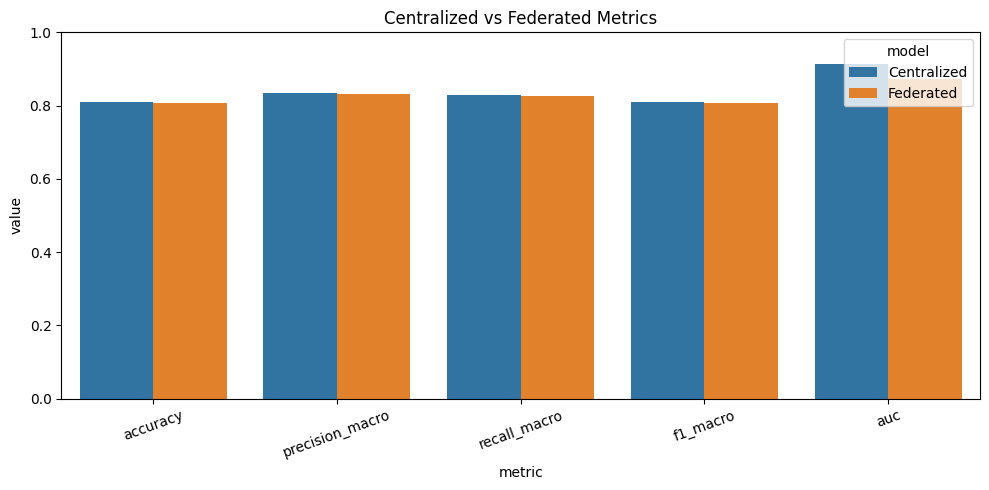

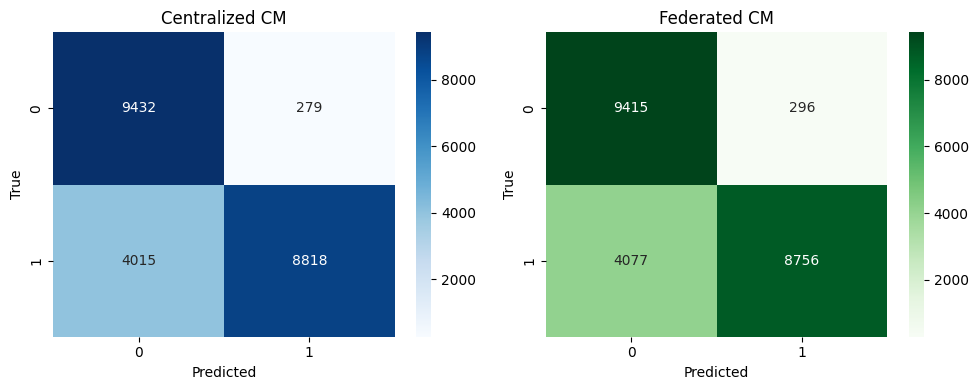

In [19]:
with open(ROOT / "baseline_metrics.json", "r", encoding="utf-8") as f:
    baseline_metrics_loaded = json.load(f)

if federated_metrics is not None:
    comparison = pd.DataFrame(
        [
            {"model": "Centralized", **{k: baseline_metrics_loaded[k] for k in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auc"]}},
            {"model": "Federated", **{k: federated_metrics[k] for k in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auc"]}},
        ]
    )
    print(comparison)

    comparison.to_csv(ROOT / "results_comparison.csv", index=False)
    print("Saved results_comparison.csv")

    melted = comparison.melt(id_vars="model", var_name="metric", value_name="value")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=melted, x="metric", y="value", hue="model")
    plt.ylim(0, 1)
    plt.title("Centralized vs Federated Metrics")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    cm_base = np.array(baseline_metrics_loaded["confusion_matrix"])
    cm_fed = np.array(federated_metrics["confusion_matrix"])

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues", ax=axs[0])
    axs[0].set_title("Centralized CM")
    sns.heatmap(cm_fed, annot=True, fmt="d", cmap="Greens", ax=axs[1])
    axs[1].set_title("Federated CM")
    for ax in axs:
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()
else:
    print("Federated metrics not available yet. Run Phase 3 and rerun Phase 4.")

## Comparison Report

This final section compares centralized and federated metrics, saves the report CSV, and renders the summary plots.